# Pneumonia Detection with Deep Learning
## Data Preprocessing Pipeline

### Project Overview
**Author:** Mohamed Ouaddane


### Objectives
1. Dataset Loading
    - Import raw Chest X-Ray dataset from Kaggle
    - Parse train/validation/test directory structure

2. Data Analysis
    - Examine class distribution (NORMAL vs PNEUMONIA)
    - Identify and handle corrupted images
    
3. Data Preparation  
    - Resample data if needed
    - Reorganize into standardized folders:
      - `/data/train`
      - `/data/val` 
      - `/data/test`

4. Feature Engineering
    - Convert images to arrays
    - Prepare normalized input for CNN model


In [8]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split

# Paths
INPUT_DIR = "/kaggle/input/chest-xray-pneumonia/chest_xray"
OUTPUT_DIR = "../data"
SPLITS = ["train", "val", "test"]

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input folder exists: {os.path.exists(INPUT_DIR)}")
print(f"Output folder created at: {os.path.abspath(OUTPUT_DIR)}")


Input folder exists: False
Output folder created at: c:\Users\DELL\Desktop\AP\Pneumonia-Detection\data


In [9]:
# List folders to check if Kaggle dataset is accessible
for split in ["train", "val", "test"]:
    split_path = os.path.join(INPUT_DIR, split)
    print(f"\n {split.upper()} contains:")
    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = os.path.join(split_path, cls)
        if os.path.exists(cls_path):
            n_files = len(os.listdir(cls_path))
            print(f"  ├── {cls}: {n_files} images")



 TRAIN contains:

 VAL contains:

 TEST contains:


In [3]:
images_by_class = {}

for split in SPLITS:
    split_path = os.path.join(INPUT_DIR, split)
    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_path = os.path.join(split_path, class_name)
        if os.path.exists(class_path):
            files = [
                os.path.join(class_path, f)
                for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            images_by_class[f"{split}_{class_name}"] = files

# Quick summary
for key, files in images_by_class.items():
    print(f"{key:<20} → {len(files)} images")



Total NORMAL: 0
Total PNEUMONIA: 0


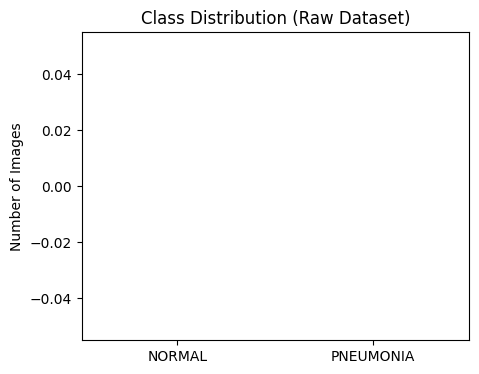

In [4]:
all_normal_files = []
all_pneumonia_files = []

for key, files in images_by_class.items():
    if "NORMAL" in key:
        all_normal_files.extend(files)
    elif "PNEUMONIA" in key:
        all_pneumonia_files.extend(files)

print(f"\nTotal NORMAL: {len(all_normal_files)}")
print(f"Total PNEUMONIA: {len(all_pneumonia_files)}")

# Quick visualization of class balance
plt.figure(figsize=(5,4))
plt.bar(["NORMAL", "PNEUMONIA"], [len(all_normal_files), len(all_pneumonia_files)], color=["#90CAF9", "#EF9A9A"])
plt.title("Class Distribution (Raw Dataset)")
plt.ylabel("Number of Images")
plt.show()


In [5]:
for split in SPLITS:
    for label in ["NORMAL", "PNEUMONIA"]:
        os.makedirs(os.path.join(OUTPUT_DIR, split, label), exist_ok=True)

print("✅ Output directory structure created successfully!")


✅ Output directory structure created successfully!


In [6]:
def split_and_save(file_list, class_name):
    train_files, temp_files = train_test_split(file_list, test_size=0.2, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

    split_dict = {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }

    for split, files in split_dict.items():
        for path in tqdm(files, desc=f"Saving {split}/{class_name}"):
            img = cv2.imread(path)
            if img is None:
                continue
            filename = os.path.basename(path)
            save_path = os.path.join(OUTPUT_DIR, split, class_name, filename)
            cv2.imwrite(save_path, img)

split_and_save(all_normal_files, "NORMAL")
split_and_save(all_pneumonia_files, "PNEUMONIA")

print("✅ Dataset reorganized successfully inside 'data/' folder.")


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [7]:
sample_normal = random.choice(all_normal_files)
sample_pneumonia = random.choice(all_pneumonia_files)

img_normal = cv2.imread(sample_normal, cv2.IMREAD_GRAYSCALE)
img_pneumonia = cv2.imread(sample_pneumonia, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_normal, cmap='gray')
plt.title("Normal Sample")

plt.subplot(1,2,2)
plt.imshow(img_pneumonia, cmap='gray')
plt.title("Pneumonia Sample")

plt.show()


IndexError: Cannot choose from an empty sequence

In [ ]:
for split in SPLITS:
    print(f"\n {split.upper()} split:")
    for cls in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(OUTPUT_DIR, split, cls)
        print(f"  {cls:<10}: {len(os.listdir(path))} images")


In [ ]:
def load_split(split_name, target_size=(224, 224), normalize=True):
    images, labels, bad_files = [], [], []
    split_path = os.path.join(OUTPUT_DIR, split_name)

    for class_name, label in zip(["NORMAL", "PNEUMONIA"], [0, 1]):
        class_path = os.path.join(split_path, class_name)
        for file in os.listdir(class_path):
            path = os.path.join(class_path, file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                bad_files.append(path)
                continue
            img = cv2.resize(img, target_size)
            if normalize:
                img = img.astype("float32") / 255.0
            img = np.expand_dims(img, axis=-1)
            images.append(img)
            labels.append(label)

    if bad_files:
        print(f"[WARNING] {len(bad_files)} corrupted images skipped.")
    return np.array(images), np.array(labels)

x_train, y_train = load_split("train")
x_val, y_val = load_split("val")
x_test, y_test = load_split("test")

print("✅ Loaded arrays:")
print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")


In [ ]:
indices = random.sample(range(len(x_train)), 20)
plt.figure(figsize=(12, 12))
for i, idx in enumerate(indices):
    plt.subplot(5, 4, i + 1)
    plt.imshow(x_train[idx].squeeze(), cmap='gray')
    plt.title("NORMAL" if y_train[idx]==0 else "PNEUMONIA", fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
np.save("data/x_train.npy", x_train)
np.save("data/y_train.npy", y_train)
np.save("data/x_val.npy", x_val)
np.save("data/y_val.npy", y_val)
np.save("data/x_test.npy", x_test)
np.save("data/y_test.npy", y_test)

print("💾 Preprocessed NumPy arrays saved in 'data/' folder.")


In [ ]:
print(" Data Preprocessing Completed Successfully!")
print(f"Training Samples: {len(y_train)}")
print(f"Validation Samples: {len(y_val)}")
print(f"Test Samples: {len(y_test)}")
